<a href="https://colab.research.google.com/github/Azidian/Inteligencia_Artificial/blob/main/Actividades/08_Lecture03_programacion_lineal/04_programacion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Programación Lineal

**Curso:** Inteligencia Artificial — Optimización (Clase 3)

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.
Los dos ejemplos son exactamente los que se formalizan en las slides de la
Clase 3, para que la transición slide → notebook no introduzca un problema
nuevo que el estudiante no haya visto formulado antes.

## Objetivos

- formular variables de decisión, función objetivo y restricciones;
- visualizar la región factible de un problema con dos variables;
- resolver un problema mediante enumeración de vértices y `scipy.optimize.linprog`;
- interpretar holguras y restricciones activas;
- convertir una restricción `≥` a la forma estándar `≤` que esperan los solvers.

![Descripción](https://drive.google.com/uc?export=view&id=1lNBEfy3ZR_bHsx-LJz1L7gip_C9ZEKSb)

## 1. Problema de producción: sillas y mesas

Una fábrica produce **sillas** ($x_1$) y **mesas** ($x_2$). Cada silla deja
\$25 de ganancia y cada mesa \$30.

| Recurso | Silla ($x_1$) | Mesa ($x_2$) | Disponible |
|---|---:|---:|---:|
| Madera | 2 unidades | 3 unidades | 120 unidades |
| Mano de obra | 1 h | 1 h | 50 h |

Modelo:

$$
\max 25x_1+30x_2
$$

sujeto a

$$
2x_1+3x_2\leq120
$$

$$
x_1+x_2\leq50
$$

$$
x_1,x_2\geq0
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

## 2. Visualización de la región factible

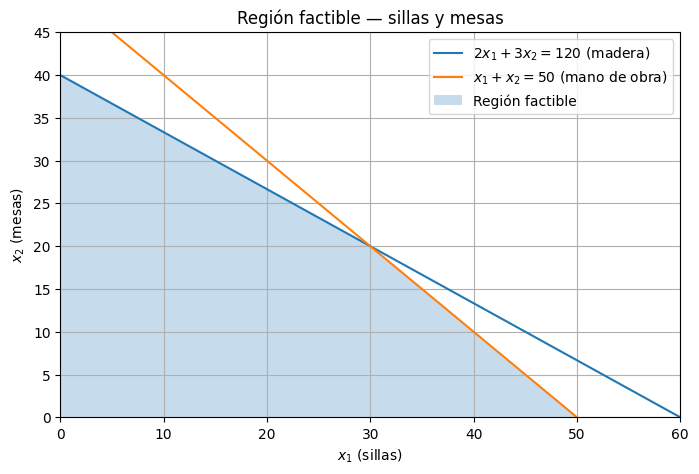

In [2]:
x1 = np.linspace(0, 60, 500)
constraint_1 = (120 - 2 * x1) / 3
constraint_2 = 50 - x1
upper = np.minimum(constraint_1, constraint_2)
upper = np.maximum(upper, 0)

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Región factible — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 3. Solución mediante vértices

En un problema lineal con una región factible acotada, si existe un óptimo, al menos un vértice es óptimo. Para dos variables podemos calcularlos explícitamente.

In [3]:
# Intersección entre las dos restricciones.
A = np.array([[2, 3], [1, 1]], dtype=float)
b = np.array([120, 50], dtype=float)
intersection = np.linalg.solve(A, b)

vertices = [
    np.array([0.0, 0.0]),
    np.array([50.0, 0.0]),   # x1 = 50 satura mano de obra antes que madera (120/2=60 > 50)
    np.array([0.0, 40.0]),   # x2 = 40 satura madera antes que mano de obra (120/3=40 < 50)
    intersection
]


def profit(x):
    return 25 * x[0] + 30 * x[1]

for vertex in vertices:
    print(f'x={vertex}, utilidad={profit(vertex):.2f}')

best_vertex = max(vertices, key=profit)
print()
print('Mejor vértice:', best_vertex)
print('Utilidad máxima:', profit(best_vertex))

x=[0. 0.], utilidad=0.00
x=[50.  0.], utilidad=1250.00
x=[ 0. 40.], utilidad=1200.00
x=[30. 20.], utilidad=1350.00

Mejor vértice: [30. 20.]
Utilidad máxima: 1350.0


Nota: con la utilidad original del ejemplo (\$20 por silla en vez de \$25),
el gradiente de la función objetivo queda exactamente paralelo a la
restricción de madera y hay **empate** entre dos vértices (óptimos
múltiples a lo largo de una arista). Con \$25 el óptimo es único — vale la
pena mencionar en clase que ese empate *sí* puede pasar en LP y no es un
error, es una propiedad real cuando el gradiente de la función objetivo
coincide en dirección con una restricción activa.

## 4. Solución con SciPy

`linprog` minimiza. Para maximizar $c^Tx$, minimizamos $-c^Tx$.

In [4]:
c = np.array([-25, -30])
A_ub = np.array([[2, 3], [1, 1]])
b_ub = np.array([120, 50])
bounds = [(0, None), (0, None)]

result = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

if not result.success:
    raise RuntimeError(result.message)

print('Solución:', result.x)
print('Utilidad máxima:', -result.fun)
print('Holguras:', result.ineqlin.residual)

Solución: [30. 20.]
Utilidad máxima: 1350.0
Holguras: [0. 0.]


Una holgura igual a cero indica que la restricción está **activa** en la solución. En este problema, ambos recursos se usan completamente.

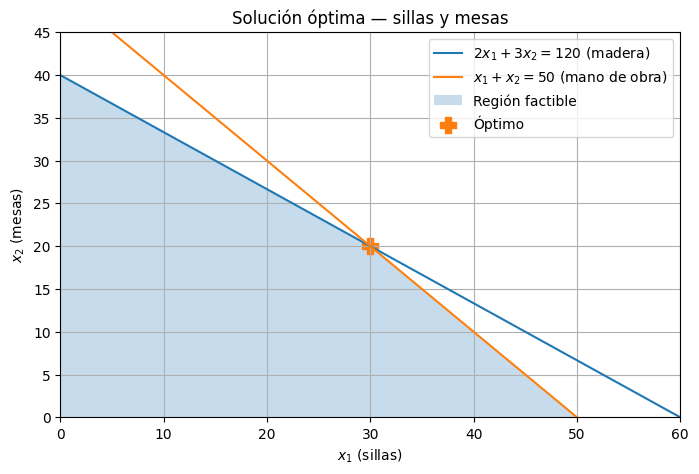

In [5]:
solution = result.x

plt.figure(figsize=(8, 5))
plt.plot(x1, constraint_1, label=r'$2x_1+3x_2=120$ (madera)')
plt.plot(x1, constraint_2, label=r'$x_1+x_2=50$ (mano de obra)')
plt.fill_between(x1, 0, upper, where=(upper >= 0), alpha=0.25, label='Región factible')
plt.scatter([solution[0]], [solution[1]], s=130, marker='P', label='Óptimo')
plt.xlim(0, 60)
plt.ylim(0, 45)
plt.xlabel(r'$x_1$ (sillas)')
plt.ylabel(r'$x_2$ (mesas)')
plt.title('Solución óptima — sillas y mesas')
plt.legend()
plt.grid(True)
plt.show()

## 5. Análisis de sensibilidad básico

Modificaremos la utilidad de la mesa y observaremos cuándo cambia la solución óptima.

In [6]:
profits_b = np.arange(10, 101, 5)
solutions = []

for p_b in profits_b:
    r = linprog([-25, -p_b], A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    solutions.append((p_b, r.x[0], r.x[1], -r.fun))

print('utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total')
for p_b, x_1, x_2, value in solutions:
    print(f'{p_b:>13.0f} | {x_1:>11.1f} | {x_2:>10.1f} | {value:>14.1f}')

utilidad_mesa | x1 (sillas) | x2 (mesas) | utilidad total
           10 |        50.0 |        0.0 |         1250.0
           15 |        50.0 |        0.0 |         1250.0
           20 |        50.0 |        0.0 |         1250.0
           25 |        30.0 |       20.0 |         1250.0
           30 |        30.0 |       20.0 |         1350.0
           35 |        30.0 |       20.0 |         1450.0
           40 |         0.0 |       40.0 |         1600.0
           45 |         0.0 |       40.0 |         1800.0
           50 |         0.0 |       40.0 |         2000.0
           55 |         0.0 |       40.0 |         2200.0
           60 |         0.0 |       40.0 |         2400.0
           65 |         0.0 |       40.0 |         2600.0
           70 |         0.0 |       40.0 |         2800.0
           75 |         0.0 |       40.0 |         3000.0
           80 |         0.0 |       40.0 |         3200.0
           85 |         0.0 |       40.0 |         3400.0
           90 

## 6. Segundo ejemplo: dos máquinas (minimización)

Una variante útil porque **minimiza** en vez de maximizar, y porque obliga
a convertir una restricción `≥` a la forma estándar `≤` que espera
`linprog`. Este es el mismo ejemplo que aparece formulado en la slide de
la Clase 3.

- Dos máquinas $x_1, x_2$ (horas de uso). $x_1$ cuesta \$50/hora, $x_2$
  cuesta \$80/hora. **Minimizar**: $50x_1+80x_2$.
- Mano de obra disponible: $x_1$ requiere 5 unidades/hora, $x_2$ requiere
  2 unidades/hora, con 20 unidades totales disponibles:
  $5x_1+2x_2\leq20$.
- Producción mínima requerida: $x_1$ produce 10 unidades/hora, $x_2$
  produce 12 unidades/hora, y se necesitan al menos 90 unidades:
  $10x_1+12x_2\geq90$.

`linprog` solo acepta restricciones en la forma $\leq$, así que
multiplicamos la segunda restricción por $-1$:
$-10x_1-12x_2\leq-90$.

In [7]:
c_machines = [50, 80]
A_ub_machines = [[5, 2], [-10, -12]]
b_ub_machines = [20, -90]

result_machines = linprog(
    c_machines,
    A_ub=A_ub_machines,
    b_ub=b_ub_machines,
    bounds=[(0, None), (0, None)],
    method='highs'
)

if result_machines.success:
    print(f"X1: {round(result_machines.x[0], 2)} horas")
    print(f"X2: {round(result_machines.x[1], 2)} horas")
    print(f"Costo mínimo: {round(result_machines.fun, 2)}")
else:
    print("No solution")

X1: 1.5 horas
X2: 6.25 horas
Costo mínimo: 575.0


## Actividades

### Actividad 1 — Restricción adicional

Agrega una restricción de almacenamiento al problema de sillas y mesas:

$$
4x_1+2x_2\leq160
$$

Grafica la nueva región factible y resuelve el modelo.

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog

# Función objetivo: maximizar Z = 25*x1 + 30*x2 -> minimizamos -25*x1 - 30*x2
c = [-25, -30]

# Matriz de restricciones de desigualdad (<=)
# Fila 1: Madera       (2x1 + 3x2 <= 120)
# Fila 2: Mano de obra (1x1 + 1x2 <= 50)
# Fila 3: Almacenamiento (4x1 + 2x2 <= 160)
A_ub_extended = [[2, 3], [1, 1], [4, 2]]

b_ub_extended = [120, 50, 160]

# Cotas de no negatividad (x1 >= 0, x2 >= 0)
bounds = [(0, None), (0, None)]

# Resolver con el solver HiGHS
result_extended = linprog(
    c, A_ub=A_ub_extended, b_ub=b_ub_extended, bounds=bounds, method="highs"
)

# Mostrar resultados numéricos
print(f"Estado: {result_extended.message}")
print(f"Sillas óptimas (x1): {result_extended.x[0]:.0f}")
print(f"Mesas óptimas (x2):  {result_extended.x[1]:.0f}")
print(f"Ganancia máxima (Z): ${-result_extended.fun:.2f}")
print(
    f"Holgura de recursos [Madera, Mano obra, Almacenamiento]: {result_extended.slack}"
)

Estado: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Sillas óptimas (x1): 30
Mesas óptimas (x2):  20
Ganancia máxima (Z): $1350.00
Holgura de recursos [Madera, Mano obra, Almacenamiento]: [0. 0. 0.]


Grafica:

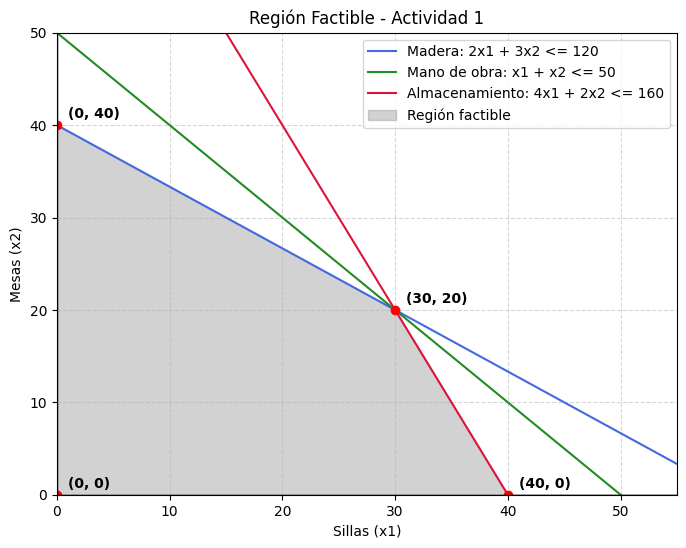

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Rango de valores para x1
x1 = np.linspace(0, 60, 400)

# Ecuaciones frontera de las restricciones: x2 = f(x1)
x2_madera = (120 - 2 * x1) / 3
x2_obra = 50 - x1
x2_almacen = (160 - 4 * x1) / 2

plt.figure(figsize=(8, 6))

# Trazado de las rectas con texto plano (evita errores de LaTeX)
plt.plot(x1, x2_madera, label="Madera: 2x1 + 3x2 <= 120", color="royalblue")
plt.plot(x1, x2_obra, label="Mano de obra: x1 + x2 <= 50", color="forestgreen")
plt.plot(
    x1, x2_almacen, label="Almacenamiento: 4x1 + 2x2 <= 160", color="crimson"
)

# Delimitación no negativa de la región factible
x2_factible = np.minimum(np.minimum(x2_madera, x2_obra), x2_almacen)
x2_factible = np.maximum(0, x2_factible)

plt.fill_between(
    x1, 0, x2_factible, color="gray", alpha=0.35, label="Región factible"
)

# Dibujar y etiquetar los vértices
vertices = [(0, 0), (40, 0), (30, 20), (0, 40)]
for vx, vy in vertices:
    plt.plot(vx, vy, "ro", markersize=6)
    plt.annotate(
        f"({vx}, {vy})",
        (vx, vy),
        textcoords="offset points",
        xytext=(8, 5),
        ha="left",
        fontweight="bold",
    )

# Configuración de ejes y estética
plt.xlim(0, 55)
plt.ylim(0, 50)
plt.xlabel("Sillas (x1)")
plt.ylabel("Mesas (x2)")
plt.title("Región Factible - Actividad 1")
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Actividad 2 — Producción mínima

El contrato exige producir al menos 10 mesas:

$$
x_2\geq10
$$

Representa esta condición correctamente en `linprog` y resuelve el problema de sillas y mesas.


In [9]:
# Cota inferior para x2 modificada a 10
bounds_min_tables = [(0, None), (10, None)]

result_min = linprog(
    c,
    A_ub=A_ub_extended,
    b_ub=b_ub_extended,
    bounds=bounds_min_tables,
    method="highs",
)

print(
    f"Solución con mínimo de mesas: x1 = {result_min.x[0]:.0f}, x2 = {result_min.x[1]:.0f}"
)
print(f"Ganancia máxima (Z) = ${-result_min.fun:.2f}")

Solución con mínimo de mesas: x1 = 30, x2 = 20
Ganancia máxima (Z) = $1350.00


### Actividad 3 — Inviabilidad

Crea una restricción adicional que vuelva el problema de sillas y mesas inviable. Comprueba el estado retornado por SciPy y explica qué significa.

In [10]:
# Restricción imposible: x1 + x2 >= 100
A_infeasible = [[2, 3], [1, 1], [-1, -1]]
b_infeasible = [120, 50, -100]

result_infeasible = linprog(
    c, A_ub=A_infeasible, b_ub=b_infeasible, bounds=bounds, method="highs"
)

print(f"Éxito: {result_infeasible.success}")
print(f"Código de estado: {result_infeasible.status}")
print(f"Mensaje de SciPy: {result_infeasible.message}")

Éxito: False
Código de estado: 2
Mensaje de SciPy: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status is None)


### Actividad 4 — Variables enteras

¿Tiene sentido producir 37.5 sillas? Investiga la diferencia conceptual entre programación lineal y programación lineal entera. No es necesario implementar un solver entero en este notebook.

En la práctica, no se pueden vender unidades compuestas a la mitad (a menos que representen lotes o trabajo en proceso). Las unidades físicas discretas exigen valores enteros.
- **Programación Lineal (LP) vs. Programación Lineal Entera (ILP/MILP):**
  - **LP (Continua):** Admite $x_i \in \mathbb{R}_{\ge 0}$. La región factible es un poliedro convexo y la solución óptima siempre coincide con un vértice o cara del mismo. Se resuelve en tiempo polinomial (Simplex/Puntos Interiores).
  - **ILP (Entera):** Exige $x_i \in \mathbb{Z}_{\ge 0}$. La región factible se convierte en una rejilla discreta de puntos dentro del poliedro. Es un problema NP-duro que requiere algoritmos combinatorios (como Branch & Bound o planos de corte).
  
  *Redondear la solución continua de LP no garantiza factibilidad ni optimalidad en ILP.*

### Actividad 5 — El empate de la Sección 3

Vuelve a correr la Sección 3 con la utilidad original de \$20 por silla en
vez de \$25. Verifica que (0,40) y (30,20) empatan, y explica en tus
palabras por qué el problema de las dos máquinas de la Sección 6 no
tiene ese mismo riesgo (piensa en la relación entre el gradiente de la
función objetivo y las normales de las restricciones activas).

In [11]:
c_original = [-20, -30]  # Utilidad de 20 por silla
result_tie = linprog(
    c_original, A_ub=[[2, 3], [1, 1]], b_ub=[120, 50], bounds=bounds, method="highs"
)

z_D = 20 * 0 + 30 * 40  # Punto (0, 40)
z_C = 20 * 30 + 30 * 20  # Punto (30, 20)

print(f"Ganancia en (0,40): ${z_D}")
print(f"Ganancia en (30,20): ${z_C}")

Ganancia en (0,40): $1200
Ganancia en (30,20): $1200


## Preguntas de cierre

1. ¿Qué diferencia hay entre una restricción y la función objetivo?

R: La función objetivo define la meta del problema (maximizar ganancias o minimizar costos). Las restricciones establecen los límites físicos o funcionales del sistema (recursos limitados, requerimientos mínimos) que restringen el espacio de decisión.

2. ¿Qué significa que una solución sea factible?

R: Es cualquier combinación de variables $(x_1, x_2)$ que cumple todas y cada una de las restricciones del modelo simultáneamente, incluyendo las condiciones de no negatividad.

3. ¿Por qué `linprog` recibe el negativo de las utilidades al maximizar?

R: SciPy implementa linprog internamente como un algoritmo de minimización ($\min c^T x$). Por propiedad matemática, maximizar $f(x)$ equivale a minimizar $-f(x)$: $\max Z \iff \min (-Z)$.

4. ¿Toda solución óptima usa por completo todos los recursos?

R: No. Un recurso solo se agota por completo si la restricción correspondiente está activa en la solución óptima (holgura $= 0$). Si la restricción es inactiva, existirá un sobrante o holgura ($slack > 0$).

5. ¿Puede un problema de LP tener más de una solución óptima? ¿Bajo qué condición geométrica ocurre?

R: Sí. Ocurre cuando la recta/hiperplano de nivel de la función objetivo es paralela a una de las aristas o caras de la región factible (es decir, el vector gradiente de $Z$ es proporcional/colineal al vector normal de una restricción activa). En este caso, todos los puntos sobre ese segmento o cara son igualmente óptimos.